# Lesson Coverage

Use the following checklist.

## Behind .fit()

- [x] Hypothesis Function
- [x] X / y / beta
- [x] LinearRegression.fit()
- [x] intercept_
- [x] coef_
- [x] Prediction from learned beta
- [x] Residual
- [x] OLS / Squared Loss
- [x] Loss minimization concept

## Gradient Descent

- [x] Manual Gradient Descent
- [x] Partial Derivative
- [x] Gradient Vector
- [x] Parameter Update Rule
- [x] Learning Rate
- [x] Epoch
- [x] Minimum Step Size
- [x] Maximum Epochs
- [x] Convergence
- [x] Multi-parameter Gradient Descent
- [ ] Scaling effect

## OLS Geometry

- [ ] Column Space concept
- [ ] Orthogonal Projection concept
- [ ] X^T residual approximately zero

## Other Solvers

- [ ] Batch Gradient Descent
- [ ] Mini-Batch Gradient Descent
- [ ] SGD
- [ ] SGDRegressor
- [ ] SGDClassifier
- [ ] LinearRegression vs SGDRegressor
- [ ] Solver scaling benchmark
- [ ] Momentum concept
- [ ] AdaGrad concept
- [ ] RMSProp concept
- [ ] Adam concept
- [ ] Newton / Second-Order concept
- [ ] L-BFGS concept

## Regression Losses

- [ ] L1 / MAE
- [ ] L2 / MSE
- [ ] Huber Loss
- [ ] SGDRegressor squared_error
- [ ] SGDRegressor huber

## Classification Losses

- [ ] Binary classification target
- [ ] Logistic probability concept
- [ ] Likelihood / Log-Likelihood concept
- [ ] Log Loss / Cross-Entropy
- [ ] SGDClassifier log_loss
- [ ] Hinge Loss
- [ ] SGDClassifier hinge
- [ ] LogisticRegression newton-cg
- [ ] LogisticRegression lbfgs

## Final Concepts

- [ ] Loss vs Performance Metric
- [ ] Parameter vs Hyperparameter
- [ ] Hypothesis vs Loss vs Solver
- [ ] Final training chain

# 1. Load California Housing Dataset

We load the California Housing dataset directly from `sklearn.datasets.fetch_california_housing(as_frame=True)`.
The goal of this project is to inspect the training and optimization process behind machine learning estimators.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load dataset as pandas dataframe
housing = fetch_california_housing(as_frame=True)
data = housing.frame

print("Loaded California Housing dataset:")
print(f"data.shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()

Loaded California Housing dataset:
data.shape: (20640, 9)
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


# 2. Minimal Data Audit

This lesson is focused on **Training and Optimization**, not data preprocessing or cleaning.
We perform a minimal structural audit to confirm data integrity:
- Target column `MedHouseVal` is expressed in units of **$100,000**.
- The dataset is strictly numerical with no missing values and no duplicate rows.
- No feature scaling, cleaning, or outlier removal is required for the baseline one-feature demonstration.

In [2]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
print("Missing values per column:")
print(data.isnull().sum())
print(f"\nTotal duplicate rows: {data.duplicated().sum()}")

Missing values per column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Total duplicate rows: 0


In [4]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


# 3. Define Feature Matrix X and Target Vector y

For this initial lesson step, we isolate a single input feature:
- **Feature $X$**: `MedInc` (Median income in block group)
- **Target $y$**: `MedHouseVal` (Median house value)

### Notation:
- $X$ is the design / feature matrix.
- $y$ is the ground-truth observation target.
- $\beta$ represents the parameters that the estimator will learn during `.fit()`.

In [5]:
X = data[["MedInc"]]
y = data["MedHouseVal"]

print(f"X shape: {X.shape} (Feature: {list(X.columns)})")
print(f"y shape: {y.shape} (Target: {y.name})")

X shape: (20640, 1) (Feature: ['MedInc'])
y shape: (20640,) (Target: MedHouseVal)


# 4. Train / Test Split

We partition the data into an 80% training set and a 20% test set using `random_state=42`.
No scaling or stratification is performed.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

X_train shape: (16512, 1), y_train shape: (16512,)
X_test shape:  (4128, 1), y_test shape:  (4128,)


# 5. Linear Regression Baseline & Learned Parameters

We fit `LinearRegression()` on `(X_train, y_train)` and inspect the learned parameters:
- **Intercept**: `model.intercept_` (corresponds to $\beta_0$)
- **Slope / Coefficient**: `model.coef_[0]` (corresponds to $\beta_1$)

In [7]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

beta_0 = model.intercept_
beta_1 = model.coef_[0]

print(f"Learned beta_0 (intercept_): {beta_0:.6f}")
print(f"Learned beta_1 (coef_[0]):   {beta_1:.6f}")

Learned beta_0 (intercept_): 0.444597
Learned beta_1 (coef_[0]):   0.419338


# 6. The Hypothesis Function

In machine learning regression, the hypothesis function maps inputs $X$ and parameters $\beta$ to a prediction $\hat{y}$:
$$y = h(X, \beta) + \varepsilon$$
$$\hat{y} = h(X, \beta)$$

For a single-feature linear model:
$$h(X, \beta) = \beta_0 + \beta_1 \cdot \text{MedInc}$$

We define this mathematical function explicitly and verify that manual evaluation matches `model.predict()`.

In [8]:
def h(x, beta_0, beta_1):
    """Manual hypothesis function: h(x, beta) = beta_0 + beta_1 * x"""
    return beta_0 + beta_1 * x

# Check manual predictions against scikit-learn on the first 5 test samples
sample_x = X_test.iloc[:5]["MedInc"].values
manual_sample_preds = h(sample_x, beta_0, beta_1)
sklearn_sample_preds = model.predict(X_test.iloc[:5])

for i, (val_x, m_pred, sk_pred) in enumerate(zip(sample_x, manual_sample_preds, sklearn_sample_preds)):
    print(f"Sample {i}: MedInc={val_x:.4f} -> Manual h(x)={m_pred:.6f} | model.predict={sk_pred:.6f}")

assert np.allclose(manual_sample_preds, sklearn_sample_preds), "Manual predictions do not match model.predict!"
print("\nVerification confirmed: Manual hypothesis evaluations match model.predict() exactly.")

Sample 0: MedInc=1.6812 -> Manual h(x)=1.149589 | model.predict=1.149589
Sample 1: MedInc=2.5313 -> Manual h(x)=1.506069 | model.predict=1.506069
Sample 2: MedInc=3.4801 -> Manual h(x)=1.903937 | model.predict=1.903937
Sample 3: MedInc=5.7376 -> Manual h(x)=2.850594 | model.predict=2.850594
Sample 4: MedInc=3.7250 -> Manual h(x)=2.006633 | model.predict=2.006633

Verification confirmed: Manual hypothesis evaluations match model.predict() exactly.


# 7. Model Predictions

We generate predictions across the full test set and construct a comparison table.

In [9]:
y_pred = model.predict(X_test)

prediction_check = pd.DataFrame({
    "MedInc": X_test["MedInc"],
    "actual": y_test,
    "predicted": y_pred
})

prediction_check.head(10)

,MedInc,actual,predicted
20046,1.6812,0.47700,1.149589
3024,2.5313,0.45800,1.506069
15663,3.4801,5.00001,1.903937
20484,5.7376,2.18600,2.850594
9814,3.7250,2.78000,2.006633
13311,4.7147,1.58700,2.421652
7113,5.0839,1.98200,2.576472
7668,3.6908,1.57500,1.992292
18246,4.8036,3.40000,2.458932
5723,8.1132,4.46600,3.846774


# 8. Residuals

The residual is the difference between actual ground-truth target and model prediction:
$$\text{Residual}_i = y_i - \hat{y}_i$$

In [10]:
residuals = y_test - y_pred
prediction_check["residual"] = residuals

print("First 10 test predictions with residuals:")
prediction_check.head(10)

First 10 test predictions with residuals:


,MedInc,actual,predicted,residual
20046,1.6812,0.47700,1.149589,-0.672589
3024,2.5313,0.45800,1.506069,-1.048069
15663,3.4801,5.00001,1.903937,3.096073
20484,5.7376,2.18600,2.850594,-0.664594
9814,3.7250,2.78000,2.006633,0.773367
13311,4.7147,1.58700,2.421652,-0.834652
7113,5.0839,1.98200,2.576472,-0.594472
7668,3.6908,1.57500,1.992292,-0.417292
18246,4.8036,3.40000,2.458932,0.941068
5723,8.1132,4.46600,3.846774,0.619226


# 9. OLS / Squared Loss

Ordinary Least Squares (OLS) chooses parameters $\beta$ that minimize the sum of squared errors:
$$\text{SSR} = \sum_{i=1}^N (y_i - \hat{y}_i)^2$$
$$\text{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$$

We compute both SSR and MSE on the test set.

In [11]:
ssr = np.sum(residuals ** 2)
mse = np.mean(residuals ** 2)

print(f"Sum of Squared Residuals (SSR): {ssr:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")

Sum of Squared Residuals (SSR): 2927.2299
Mean Squared Error (MSE):       0.7091


# 10. Manual Loss Check Around Learned $\beta$

To demonstrate the concept of **loss minimization** before introducing Gradient Descent:
1. We keep $\beta_1$ fixed at the learned value.
2. We evaluate alternative candidate $\beta_0$ values in a neighborhood around the learned intercept ($\beta_0 \pm \delta$).
3. We compute the training Sum of Squared Residuals (SSR) for each candidate.

Because `.fit()` minimizes the training squared-error objective, the learned $\beta_0$ must produce a lower loss than any nearby alternative.

In [12]:
fixed_beta_1 = beta_1
deltas = [-0.20, -0.10, -0.05, 0.0, 0.05, 0.10, 0.20]

X_tr_vals = X_train["MedInc"].values
y_tr_vals = y_train.values

loss_comparison = []
for d in deltas:
    cand_b0 = beta_0 + d
    cand_preds = h(X_tr_vals, cand_b0, fixed_beta_1)
    cand_ssr = np.sum((y_tr_vals - cand_preds) ** 2)
    cand_mse = np.mean((y_tr_vals - cand_preds) ** 2)
    loss_comparison.append({
        "delta": d,
        "beta_0": cand_b0,
        "is_learned": (d == 0.0),
        "SSR (Train)": cand_ssr,
        "MSE (Train)": cand_mse
    })

loss_table = pd.DataFrame(loss_comparison)
loss_table

,delta,beta_0,is_learned,SSR (Train),MSE (Train)
0,-0.20,0.244597,False,12204.757567,0.739145
1,-0.10,0.344597,False,11709.397567,0.709145
2,-0.05,0.394597,False,11585.557567,0.701645
3,0.00,0.444597,True,11544.277567,0.699145
4,0.05,0.494597,False,11585.557567,0.701645
5,0.10,0.544597,False,11709.397567,0.709145
6,0.20,0.644597,False,12204.757567,0.739145


# 11. Visualizing the Fitted Hypothesis Line

We plot a sample of the training observations alongside the fitted hypothesis line:
$$\hat{y} = \beta_0 + \beta_1 \cdot \text{MedInc}$$

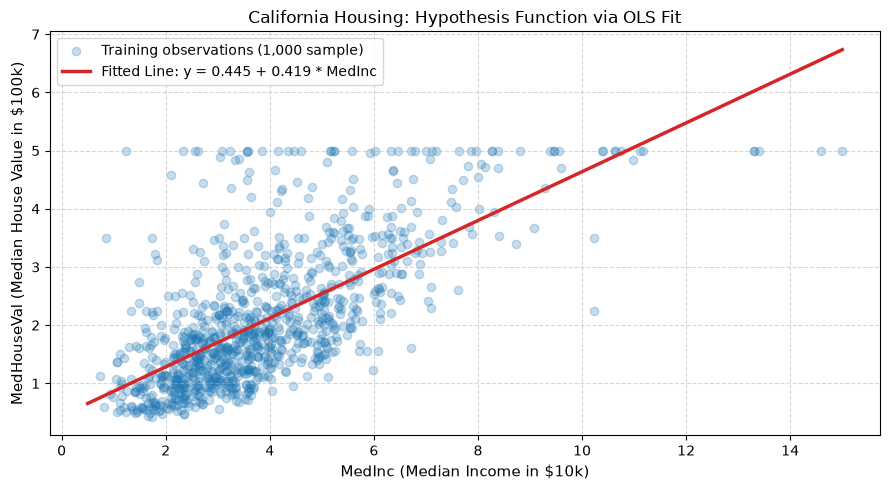

In [13]:
plt.figure(figsize=(9, 5))

# Subsample points for clear visualization
sample_idx = np.random.RandomState(42).choice(len(X_train), size=1000, replace=False)
plt.scatter(
    X_train.iloc[sample_idx]["MedInc"],
    y_train.iloc[sample_idx],
    alpha=0.25,
    color="#1f77b4",
    label="Training observations (1,000 sample)"
)

# Plot fitted regression line
x_line = np.linspace(X_train["MedInc"].min(), X_train["MedInc"].max(), 200)
y_line = h(x_line, beta_0, beta_1)
plt.plot(x_line, y_line, color="#d62728", linewidth=2.5, label=f"Fitted Line: y = {beta_0:.3f} + {beta_1:.3f} * MedInc")

plt.title("California Housing: Hypothesis Function via OLS Fit", fontsize=12)
plt.xlabel("MedInc (Median Income in $10k)", fontsize=11)
plt.ylabel("MedHouseVal (Median House Value in $100k)", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 12. Explaining What `.fit()` Did

### The Training Chain:
```
Choose Hypothesis
       ↓
   .fit(X, y)
       ↓
Solver minimizes Loss
       ↓
   Learn beta
       ↓
 Trained Model
```

- **Before `.fit()`**:
  The `LinearRegression` model is initialized with a hypothesis architecture:
  $$h(X, \beta) = \beta_0 + \beta_1 X$$
  However, it has not seen the California Housing data and parameters $\beta$ are undetermined.

- **During `.fit()`**:
  The solver identifies the optimal parameters $\beta^*$ that minimize the squared-error loss:
  $$\min_{\beta_0, \beta_1} \sum_{i=1}^N \left(y_i - (\beta_0 + \beta_1 x_i)\right)^2$$
  *Note*: scikit-learn solves this least-squares problem using numerical linear algebra (specifically Singular Value Decomposition / LAPACK `gelsd`), not brute-force iteration.

- **After `.fit()`**:
  The learned parameters are stored in:
  - `model.intercept_` ($\beta_0 = 0.444597$)
  - `model.coef_` ($\beta_1 = 0.419338$)
  Predictions can now be computed deterministically for any input value.

# 13. Parameter vs Hyperparameter Preview

- **Parameters (Learned)**:
  Values computed during `.fit()` directly from the training data:
  $$\beta_0, \beta_1$$
- **Hyperparameters (Configured)**:
  Settings chosen by the practitioner *before* calling `.fit()`, such as:
  `fit_intercept=True`, `copy_X=True`

*(A comprehensive study of hyperparameters versus parameters will be conducted in subsequent lessons.)*

# 14. Step 1 Programmatic Verification

We run automated assertions confirming all requirements of Step 1 are strictly fulfilled.

In [14]:
# Programmatic verifications
assert data.shape == (20640, 9), f"Unexpected data shape: {data.shape}"
assert len(data.columns) == 9, "Unexpected number of columns"
assert "MedHouseVal" in data.columns, "MedHouseVal target missing"
assert data.isnull().sum().sum() == 0, "Found unexpected missing values"
assert data.duplicated().sum() == 0, "Found unexpected duplicate rows"

assert X.columns.tolist() == ["MedInc"], f"X should contain only MedInc, found {X.columns.tolist()}"
assert y.name == "MedHouseVal", "y should be MedHouseVal"
assert len(X_train) == 16512 and len(X_test) == 4128, "Incorrect split sizes"
assert isinstance(model, LinearRegression), "Model is not LinearRegression"
assert np.isclose(beta_0, model.intercept_), "beta_0 mismatch"
assert np.isclose(beta_1, model.coef_[0]), "beta_1 mismatch"

# Hypothesis predictions check
test_preds = model.predict(X_test)
manual_test_preds = h(X_test["MedInc"].values, beta_0, beta_1)
assert np.allclose(test_preds, manual_test_preds), "Predictions do not match"

# Residual check
calc_residuals = y_test - test_preds
assert np.allclose(calc_residuals, residuals), "Residual mismatch"
assert ssr >= 0, "SSR must be non-negative"
assert mse >= 0, "MSE must be non-negative"

# Check that loss at learned beta_0 is strictly smaller than at candidate offsets
learned_train_ssr = np.sum((y_train.values - h(X_train["MedInc"].values, beta_0, beta_1)) ** 2)
for d in [-0.20, -0.10, -0.05, 0.05, 0.10, 0.20]:
    cand_ssr = np.sum((y_train.values - h(X_train["MedInc"].values, beta_0 + d, beta_1)) ** 2)
    assert cand_ssr > learned_train_ssr, f"Learned beta_0 is not optimal compared to delta {d}"

# Verify out-of-scope items: no scaling applied yet (raw data has mean ~3.88 and std ~1.90, not standard normal)
assert 3.5 < X_train["MedInc"].mean() < 4.2, f"Data was unexpectedly scaled! Mean: {X_train['MedInc'].mean()}"
assert 1.5 < X_train["MedInc"].std() < 2.5, f"Data was unexpectedly scaled! Std: {X_train['MedInc'].std()}"

print("✓ All Step 1 programmatic verifications passed successfully!")

✓ All Step 1 programmatic verifications passed successfully!


# 15. The Gradient Descent Idea

In machine learning, training an estimator corresponds to solving an optimization problem:
$$\text{.fit()} \longrightarrow \min_\beta \text{Loss}(\beta) \longrightarrow \text{optimal } \beta^*$$

When an exact analytical formula is unavailable or computationally expensive, we use an iterative optimization algorithm: **Gradient Descent**.

The fundamental parameter update rule is:
$$\beta_{\text{new}} = \beta_{\text{old}} - \eta \cdot \text{derivative}$$

- **Learning Rate ($\eta$)**: A positive hyperparameter that controls how large a step to take along the descent direction.
- **Derivative / Gradient**: The rate of change of the loss function with respect to parameter $\beta$. It points in the direction of steepest *ascent*; hence, subtracting it moves the parameter in the direction of steepest *descent* toward the minimum.

# 16. First Experiment: Optimizing Only $\beta_0$ (Intercept)

Following the lesson progression, we isolate the optimization process by keeping the slope parameter fixed at its learned value:
$$\text{fixed\_}\beta_1 = \beta_1 = 0.419338$$

We optimize only the intercept parameter $\beta_0$, starting from an uninformative guess:
$$\beta_0^{(0)} = 0.0$$

The hypothesis function with fixed slope is:
$$h_{\text{intercept}}(x, \beta_0) = \beta_0 + \text{fixed\_}\beta_1 \cdot x$$

### Mean Squared Error Loss and Partial Derivative
Because our dataset contains 16,512 training observations, we optimize the **Mean Squared Error (MSE)** rather than raw sum-of-squares. This keeps the gradient magnitude normalized and independent of dataset sample size:
$$\text{Loss}(\beta_0) = \frac{1}{N} \sum_{i=1}^N \left(y_i - (\beta_0 + \text{fixed\_}\beta_1 \cdot x_i)\right)^2$$

Taking the partial derivative with respect to $\beta_0$:
$$\frac{\partial \text{Loss}}{\partial \beta_0} = \frac{1}{N} \sum_{i=1}^N -2 \left(y_i - (\beta_0 + \text{fixed\_}\beta_1 \cdot x_i)\right) = \text{mean}\left(-2 \cdot (y - \hat{y})\right)$$

In [15]:
fixed_beta_1 = beta_1
X_tr_vals = X_train["MedInc"].values
y_tr_vals = y_train.values

def h_intercept_only(x, b0):
    """Hypothesis with slope fixed at learned beta_1."""
    return b0 + fixed_beta_1 * x

def compute_loss_b0(b0):
    """Mean squared error loss w.r.t b0."""
    preds = h_intercept_only(X_tr_vals, b0)
    return float(np.mean((y_tr_vals - preds) ** 2))

def compute_derivative_b0(b0):
    """Partial derivative dLoss/db0."""
    preds = h_intercept_only(X_tr_vals, b0)
    return float(np.mean(-2 * (y_tr_vals - preds)))

print("Definitions complete.")

Definitions complete.


# 17. Manual Calculation of Epoch 0 and Epoch 1

Before running an automated loop, we calculate the first two epochs explicitly step by step.
We use a stable learning rate:
$$\eta = 0.1$$

*Numerical Stability Rationale*:  
The second derivative of MSE w.r.t. $\beta_0$ is $\frac{\partial^2 \text{Loss}}{\partial \beta_0^2} = 2$. The theoretical upper bound for convergence of gradient descent on a quadratic with curvature $L=2$ is $\eta < \frac{2}{L} = 1.0$. Setting $\eta = 0.1$ guarantees smooth, stable convergence well inside the stability region.

In [16]:
eta_b0 = 0.1

# --- EPOCH 0 ---
b0_epoch0 = 0.0
loss_epoch0 = compute_loss_b0(b0_epoch0)
deriv_epoch0 = compute_derivative_b0(b0_epoch0)
step_size_epoch0 = eta_b0 * deriv_epoch0

# Parameter update rule: beta_new = beta_old - eta * derivative
b0_epoch1 = b0_epoch0 - step_size_epoch0

print("=== EPOCH 0 ===")
print(f"Starting beta_0:   {b0_epoch0:.6f}")
print(f"Loss (MSE):        {loss_epoch0:.6f}")
print(f"Derivative:        {deriv_epoch0:.6f}")
print(f"Step (eta * dL):   {step_size_epoch0:.6f}")
print(f"Updated beta_0:    {b0_epoch1:.6f}")

# --- EPOCH 1 ---
loss_epoch1 = compute_loss_b0(b0_epoch1)
deriv_epoch1 = compute_derivative_b0(b0_epoch1)
step_size_epoch1 = eta_b0 * deriv_epoch1
b0_epoch2 = b0_epoch1 - step_size_epoch1

print("\n=== EPOCH 1 ===")
print(f"Starting beta_0:   {b0_epoch1:.6f}")
print(f"Loss (MSE):        {loss_epoch1:.6f}")
print(f"Derivative:        {deriv_epoch1:.6f}")
print(f"Step (eta * dL):   {step_size_epoch1:.6f}")
print(f"Updated beta_0:    {b0_epoch2:.6f}")

=== EPOCH 0 ===
Starting beta_0:   0.000000
Loss (MSE):        0.896811
Derivative:        -0.889195
Step (eta * dL):   -0.088919
Updated beta_0:    0.088919

=== EPOCH 1 ===
Starting beta_0:   0.088919
Loss (MSE):        0.825651
Derivative:        -0.711356
Step (eta * dL):   -0.071136
Updated beta_0:    0.160055


# 18. Iterative Optimization Loop for $\beta_0$

We now run the optimization loop until either:
1. **Minimum step size** is reached: $|\text{step\_size}| < 10^{-6}$ (gradient is practically zero, indicating convergence).
2. **Maximum epochs** is reached: `max_epochs = 1000` (safety termination).

In [17]:
b0_current = 0.0
max_epochs = 1000
min_step_size = 1e-6

history_b0 = []
stopping_reason_b0 = ""

for epoch in range(max_epochs):
    loss_val = compute_loss_b0(b0_current)
    deriv_val = compute_derivative_b0(b0_current)
    step_val = eta_b0 * deriv_val
    
    history_b0.append({
        "epoch": epoch,
        "beta_0": b0_current,
        "loss": loss_val,
        "derivative": deriv_val,
        "step_size": step_val
    })
    
    if abs(step_val) < min_step_size:
        stopping_reason_b0 = f"Minimum step size reached (|step| = {abs(step_val):.2e} < {min_step_size})"
        break
        
    b0_current -= step_val
else:
    stopping_reason_b0 = "Maximum epochs reached"

b0_df = pd.DataFrame(history_b0)

print(f"Convergence Reason: {stopping_reason_b0}")
print(f"Total Epochs Run:   {len(b0_df)}")
print(f"Final beta_0:       {b0_current:.6f}")
print(f"Final Loss (MSE):   {history_b0[-1]['loss']:.6f}")
b0_df.head(6)

Convergence Reason: Minimum step size reached (|step| = 8.12e-07 < 1e-06)
Total Epochs Run:   53
Final beta_0:       0.444593
Final Loss (MSE):   0.699145


,epoch,beta_0,loss,derivative,step_size
0,0,0.000000,0.896811,-0.889195,-0.088919
1,1,0.088919,0.825651,-0.711356,-0.071136
2,2,0.160055,0.780109,-0.569085,-0.056908
3,3,0.216963,0.750962,-0.455268,-0.045527
4,4,0.262490,0.732308,-0.364214,-0.036421
5,5,0.298912,0.720369,-0.291371,-0.029137


# 19. Comparison: Manual Gradient Descent vs Scikit-Learn $\beta_0$

We compare the manually converged intercept parameter against `model.intercept_` from Scikit-Learn.

In [18]:
manual_b0 = b0_current
sklearn_b0 = beta_0
diff_b0 = abs(manual_b0 - sklearn_b0)

print(f"Manual Gradient Descent beta_0: {manual_b0:.6f}")
print(f"Scikit-Learn intercept_:        {sklearn_b0:.6f}")
print(f"Absolute Difference:            {diff_b0:.8f}")

assert diff_b0 < 1e-4, "Manual beta_0 should closely match the analytical solution!"
print("\nConfirmed: Manual gradient descent converged to the exact analytical intercept.")

Manual Gradient Descent beta_0: 0.444593
Scikit-Learn intercept_:        0.444597
Absolute Difference:            0.00000406

Confirmed: Manual gradient descent converged to the exact analytical intercept.


# 20. Loss Trajectory Across Epochs

We plot the MSE loss curve as a function of epoch during the optimization of $\beta_0$.

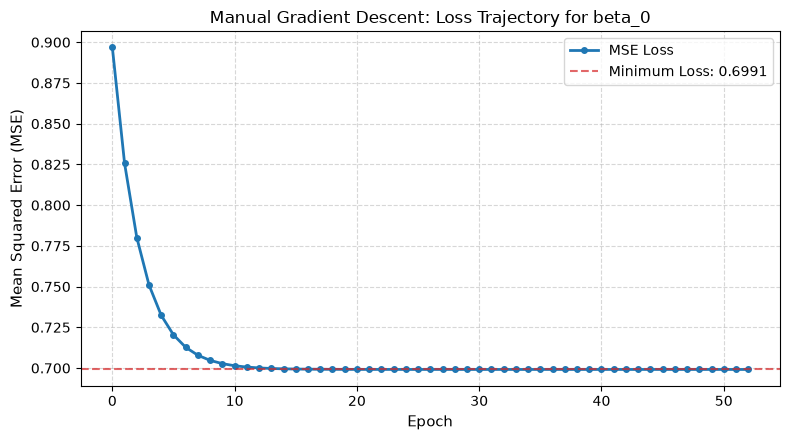

In [19]:
plt.figure(figsize=(8, 4.5))
plt.plot(b0_df["epoch"], b0_df["loss"], color="#1f77b4", linewidth=2, marker="o", markersize=4, label="MSE Loss")
plt.axhline(history_b0[-1]["loss"], color="#d62728", linestyle="--", alpha=0.7, label=f"Minimum Loss: {history_b0[-1]['loss']:.4f}")
plt.title("Manual Gradient Descent: Loss Trajectory for beta_0", fontsize=12)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Mean Squared Error (MSE)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 21. Empirical Learning Rate Regimes

The behavior of Gradient Descent depends critically on the choice of learning rate $\eta$:
- **Clearly small ($\eta = 0.01$)**: Steps are tiny; convergence is excessively slow.
- **Reasonable ($\eta = 0.20$)**: Steps make steady progress toward the minimum.
- **Intentionally too large ($\eta = 1.05$)**: The update overshoots the valley, resulting in growing oscillation and divergence (since $\eta > 1.0$).

We run each learning rate for 25 epochs from $\beta_0 = 0.0$ and observe the results.

In [20]:
test_etas = [0.01, 0.20, 1.05]
lr_experiment_records = []
lr_trajectories = {}

for eta in test_etas:
    b0_test = 0.0
    losses = []
    for ep in range(25):
        loss_val = compute_loss_b0(b0_test)
        losses.append(loss_val)
        deriv_val = compute_derivative_b0(b0_test)
        b0_test -= eta * deriv_val
        
    lr_trajectories[eta] = losses
    
    if losses[-1] > losses[0]:
        behavior = "oscillation / divergence"
    elif abs(losses[-1] - history_b0[-1]['loss']) < 1e-3:
        behavior = "stable convergence"
    else:
        behavior = "slow convergence"
        
    lr_experiment_records.append({
        "learning_rate": eta,
        "initial_loss": losses[0],
        "final_loss": losses[-1],
        "final_beta_0": b0_test,
        "behavior": behavior
    })

lr_df = pd.DataFrame(lr_experiment_records)
lr_df

,learning_rate,initial_loss,final_loss,final_beta_0,behavior
0,0.01,0.896811,0.774097,0.176299,slow convergence
1,0.20,0.896811,0.699145,0.444596,stable convergence
2,1.05,0.896811,19.876226,5.261678,oscillation / divergence


# 22. Visualizing Learning Rate Regimes

We plot the loss trajectories of the three learning rates side by side.

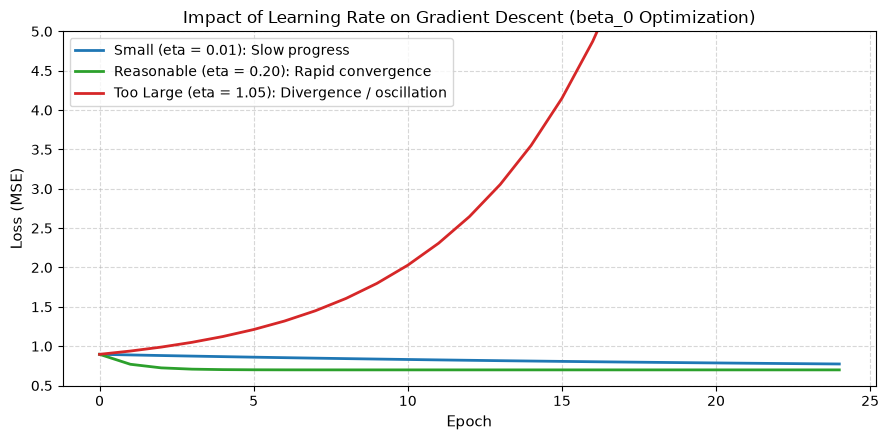

In [21]:
plt.figure(figsize=(9, 4.5))

epochs_range = list(range(25))
plt.plot(epochs_range, lr_trajectories[0.01], label="Small (eta = 0.01): Slow progress", color="#1f77b4", linewidth=2)
plt.plot(epochs_range, lr_trajectories[0.20], label="Reasonable (eta = 0.20): Rapid convergence", color="#2ca02c", linewidth=2)
plt.plot(epochs_range, lr_trajectories[1.05], label="Too Large (eta = 1.05): Divergence / oscillation", color="#d62728", linewidth=2)

plt.ylim(0.5, 5.0)  # Clipped to maintain visibility of stable curves
plt.title("Impact of Learning Rate on Gradient Descent (beta_0 Optimization)", fontsize=12)
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Loss (MSE)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

# 23. Multi-Parameter Gradient Descent (Simultaneous $\beta_0$ and $\beta_1$)

We now remove the assumption that $\beta_1$ is known and optimize both parameters simultaneously from:
$$\beta_0^{(0)} = 0, \quad \beta_1^{(0)} = 0$$

### Model Hypothesis & Loss Function
$$\hat{y} = \beta_0 + \beta_1 \cdot \text{MedInc}$$
$$\text{Loss}(\beta_0, \beta_1) = \frac{1}{N} \sum_{i=1}^N \left(y_i - (\beta_0 + \beta_1 x_i)\right)^2$$

### Partial Derivatives
$$\frac{\partial \text{Loss}}{\partial \beta_0} = \frac{1}{N} \sum_{i=1}^N -2 (y_i - \hat{y}_i) = \text{mean}(-2 \cdot (y - \hat{y}))$$
$$\frac{\partial \text{Loss}}{\partial \beta_1} = \frac{1}{N} \sum_{i=1}^N -2 x_i (y_i - \hat{y}_i) = \text{mean}(-2 \cdot X \cdot (y - \hat{y}))$$

# 24. The Gradient Vector $\nabla L(\beta)$ and Simultaneous Update Rule

The vector of all partial derivatives forms the **Gradient Vector**:
$$\nabla L(\beta) = \begin{bmatrix} \frac{\partial \text{Loss}}{\partial \beta_0} \\[6pt] \frac{\partial \text{Loss}}{\partial \beta_1} \end{bmatrix}$$

Both parameters are updated **simultaneously** using derivatives evaluated from the same previous parameter state:
$$\beta_0^{(t+1)} = \beta_0^{(t)} - \eta \cdot \frac{\partial \text{Loss}}{\partial \beta_0}\Bigg|_{(\beta_0^{(t)}, \beta_1^{(t)})}$$
$$\beta_1^{(t+1)} = \beta_1^{(t)} - \eta \cdot \frac{\partial \text{Loss}}{\partial \beta_1}\Bigg|_{(\beta_0^{(t)}, \beta_1^{(t)})}$$

*Note*: We use unscaled `MedInc` as required for this step. An empirically verified stable learning rate for the unscaled system is $\eta = 0.03$.

# 25. Multi-Parameter Optimization Loop with Diagnostics

We track:
- `gradient_norm`: $\|\nabla L(\beta)\|_2 = \sqrt{(\partial L / \partial \beta_0)^2 + (\partial L / \partial \beta_1)^2}$
- `step_norm`: $\eta \cdot \|\nabla L(\beta)\|_2$

Stopping criteria:
- `step_norm < 1e-5` (convergence)
- `epoch reaches max_epochs = 1500`

In [22]:
eta_multi = 0.03
max_epochs_multi = 1500
min_step_size_multi = 1e-5

b0_multi, b1_multi = 0.0, 0.0
multi_history = []
multi_stop_reason = ""

for epoch in range(max_epochs_multi):
    # Compute predictions from current parameter values
    y_hat = b0_multi + b1_multi * X_tr_vals
    error = y_tr_vals - y_hat
    loss_val = np.mean(error ** 2)
    
    # Compute partial derivatives from the same state
    d_b0 = float(np.mean(-2 * error))
    d_b1 = float(np.mean(-2 * X_tr_vals * error))
    
    # Construct Gradient Vector
    gradient = np.array([d_b0, d_b1])
    gradient_norm = float(np.linalg.norm(gradient))
    step_norm = float(eta_multi * gradient_norm)
    
    multi_history.append({
        "epoch": epoch,
        "beta_0": b0_multi,
        "beta_1": b1_multi,
        "loss": float(loss_val),
        "gradient_norm": gradient_norm,
        "step_norm": step_norm
    })
    
    if step_norm < min_step_size_multi:
        multi_stop_reason = f"Minimum step size reached (step_norm = {step_norm:.2e} < {min_step_size_multi})"
        break
        
    # Simultaneous update
    b0_multi -= eta_multi * d_b0
    b1_multi -= eta_multi * d_b1
else:
    multi_stop_reason = "Maximum epochs reached"

multi_df = pd.DataFrame(multi_history)

print(f"Multi-Parameter GD Stopping Reason: {multi_stop_reason}")
print(f"Total Epochs Run:                  {len(multi_df)}")
print(f"Final Manual beta_0:               {b0_multi:.6f}")
print(f"Final Manual beta_1:               {b1_multi:.6f}")
print(f"Final Training Loss (MSE):         {multi_history[-1]['loss']:.6f}")
multi_df.head(6)

Multi-Parameter GD Stopping Reason: Minimum step size reached (step_norm = 9.96e-06 < 1e-05)
Total Epochs Run:                  533
Final Manual beta_0:               0.443724
Final Manual beta_1:               0.419522
Final Training Loss (MSE):         0.699145


,epoch,beta_0,beta_1,loss,gradient_norm,step_norm
0,0,0.000000,0.000000,5.629742,19.566417,0.586993
1,1,0.124317,0.573677,0.863177,3.329185,0.099876
2,2,0.107597,0.475211,0.724906,0.579691,0.017391
3,3,0.114807,0.491037,0.720442,0.158120,0.004744
4,4,0.117900,0.487440,0.719857,0.125183,0.003756
5,5,0.121645,0.487156,0.719394,0.122758,0.003683


# 26. Comparison: Multi-Parameter Manual GD vs Scikit-Learn

We compare the parameters and final training MSE obtained from iterative Gradient Descent against the closed-form Scikit-Learn solution.

In [23]:
sklearn_train_mse = float(np.mean((y_tr_vals - model.predict(X_train)) ** 2))
manual_train_mse = multi_history[-1]["loss"]

diff_multi_b0 = abs(b0_multi - beta_0)
diff_multi_b1 = abs(b1_multi - beta_1)
diff_mse = abs(manual_train_mse - sklearn_train_mse)

print("=== OPTIMIZATION BENCHMARK ===")
print(f"Parameter beta_0: Manual = {b0_multi:.6f} | Sklearn = {beta_0:.6f} | Diff = {diff_multi_b0:.6f}")
print(f"Parameter beta_1: Manual = {b1_multi:.6f} | Sklearn = {beta_1:.6f} | Diff = {diff_multi_b1:.6f}")
print(f"Training MSE:     Manual = {manual_train_mse:.6f} | Sklearn = {sklearn_train_mse:.6f} | Diff = {diff_mse:.8f}")

assert diff_multi_b0 < 0.01, "Manual beta_0 is too far from analytical solution!"
assert diff_multi_b1 < 0.01, "Manual beta_1 is too far from analytical solution!"
assert diff_mse < 1e-4, "Training MSE should match within 1e-4!"
print("\nConfirmed: Both optimization procedures successfully converge toward the same least-squares minimum.")

=== OPTIMIZATION BENCHMARK ===
Parameter beta_0: Manual = 0.443724 | Sklearn = 0.444597 | Diff = 0.000873
Parameter beta_1: Manual = 0.419522 | Sklearn = 0.419338 | Diff = 0.000183
Training MSE:     Manual = 0.699145 | Sklearn = 0.699145 | Diff = 0.00000015

Confirmed: Both optimization procedures successfully converge toward the same least-squares minimum.


# 27. Visualizing the Parameter Trajectory in $(\beta_0, \beta_1)$ Space

We trace how the pair $(\beta_0, \beta_1)$ evolves across epochs from the initial guess $(0, 0)$ to the neighborhood of the optimal solution.

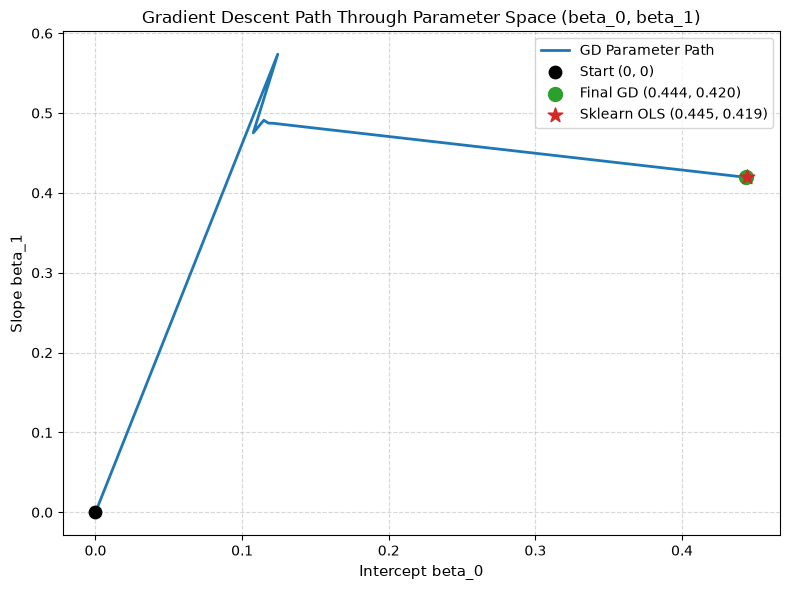

In [24]:
plt.figure(figsize=(8, 6))

plt.plot(multi_df["beta_0"], multi_df["beta_1"], color="#1f77b4", linewidth=2, label="GD Parameter Path")
plt.scatter([multi_df["beta_0"].iloc[0]], [multi_df["beta_1"].iloc[0]], color="black", s=80, zorder=5, label="Start (0, 0)")
plt.scatter([b0_multi], [b1_multi], color="#2ca02c", s=100, marker="o", zorder=5, label=f"Final GD ({b0_multi:.3f}, {b1_multi:.3f})")
plt.scatter([beta_0], [beta_1], color="#d62728", s=120, marker="*", zorder=6, label=f"Sklearn OLS ({beta_0:.3f}, {beta_1:.3f})")

plt.title("Gradient Descent Path Through Parameter Space (beta_0, beta_1)", fontsize=12)
plt.xlabel("Intercept beta_0", fontsize=11)
plt.ylabel("Slope beta_1", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 28. Convergence Mechanics & Stopping Rules

In iterative optimization, two standard criteria govern stopping:

1. **Minimum Step Size (Convergence)**:
   $$\text{step\_norm} = \eta \cdot \|\nabla L(\beta)\|_2 < \epsilon$$
   As the parameters approach the bottom of the convex loss bowl, the surface flattens and the gradient magnitude $\|\nabla L(\beta)\|$ diminishes toward zero. Consequently, each parameter step $\Delta \beta$ naturally shrinks. When step size falls below our threshold (e.g. $10^{-5}$), further updates yield negligible loss improvement, confirming empirical convergence.

2. **Maximum Epochs (Safety Limit)**:
   If an inappropriate learning rate or difficult loss geometry prevents convergence within a budgeted limit (e.g. 1500 epochs), execution halts to avoid infinite loops.

# 29. Step 2 Programmatic Verification

Automated test assertions confirming that all constraints and requirements of Step 2 are met.

In [25]:
# Verify Step 1 parameters remain unchanged
assert np.isclose(beta_0, model.intercept_), "Step 1 beta_0 was modified!"
assert np.isclose(beta_1, model.coef_[0]), "Step 1 beta_1 was modified!"

# Verify beta_0-only GD properties
assert b0_epoch0 == 0.0, "beta_0-only GD must start from zero"
assert np.isclose(fixed_beta_1, beta_1), "beta_1 must be fixed during beta_0-only GD"
assert len(history_b0) > 2, "Loop must have run multiple epochs"
assert history_b0[-1]["loss"] < history_b0[0]["loss"], "Loss must decrease under stable learning rate"

# Verify learning rate experiment
assert len(test_etas) == 3, "Learning rate experiment must contain exactly 3 distinct rates"
assert lr_df["behavior"].nunique() >= 2, "Must show distinct observable behaviors"

# Verify multi-parameter GD properties
assert multi_df["beta_0"].iloc[0] == 0.0 and multi_df["beta_1"].iloc[0] == 0.0, "Multi-parameter GD must start from (0, 0)"
assert gradient.shape == (2,), "Gradient must be a 2-element vector [d_b0, d_b1]"
assert "gradient_norm" in multi_df.columns and "step_norm" in multi_df.columns, "Must track gradient norm and step norm"
assert abs(b0_multi - beta_0) < 0.01, "Manual beta_0 should be close to sklearn solution"
assert abs(b1_multi - beta_1) < 0.01, "Manual beta_1 should be close to sklearn solution"
assert abs(multi_history[-1]["loss"] - sklearn_train_mse) < 1e-3, "Loss must match sklearn MSE closely"

# Verify out-of-scope constraints
assert 3.5 < X_train["MedInc"].mean() < 4.2, "Feature scaling must NOT be applied in Step 2!"
assert "SGDRegressor" not in globals(), "SGDRegressor must not be introduced yet!"
assert "SGDClassifier" not in globals(), "SGDClassifier must not be introduced yet!"

print("✓ All Step 2 programmatic verifications passed successfully!")

✓ All Step 2 programmatic verifications passed successfully!
